# Preprocessing

In [86]:
!pip install statsmodels


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [87]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# Load Dataset
df = pd.read_csv(r"C:\Users\Hazem\Downloads\Fifa.csv")

In [88]:
# Show first rows
df.head()

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


In [89]:
# Basic Info
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  str    
 1   Country            19667 non-null  str    
 2   Position           19667 non-null  str    
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  str    
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 1.4 MB


,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


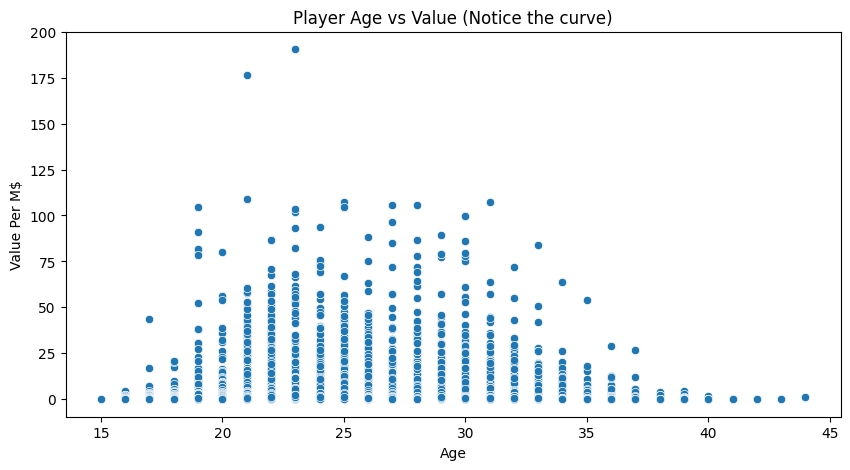

In [90]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Age', y='Value Per M$')
plt.title('Player Age vs Value (Notice the curve)')
plt.show()

**Non-linear Relationship (Bell Curve-like pattern)**

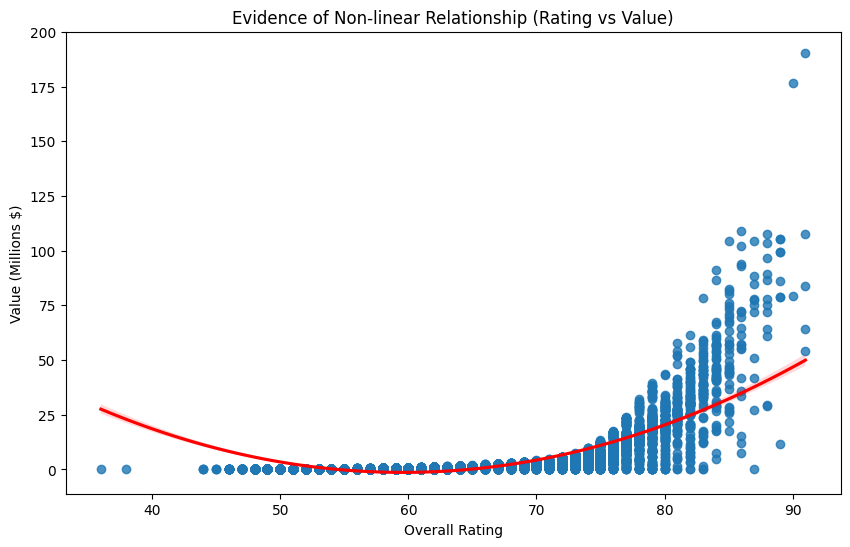

In [91]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Overall_Rating', y='Value Per M$', 
            order=2,  
            line_kws={'color': 'red'})

plt.title('Evidence of Non-linear Relationship (Rating vs Value)')
plt.xlabel('Overall Rating')
plt.ylabel('Value (Millions $)')
plt.show()

**The plot clearly shows that the relationship between (Overall_Rating) and (Value) is not a straight line,as the market value increases exponentially for top-tier players.**

**These distributions justifies the need to move beyond linear baselines and implement non-linear architectures like Tree-based or Kernel-based models to better capture these complex patterns.**

In [92]:
# Missing Values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64


In [93]:
# The dataset was checked for missing values.
# No significant missing values were found (or mention if there are any and how many).

In [94]:
def detect_outliers(df):
    num_cols = df.select_dtypes(include=np.number).columns
    
    Q1 = df[num_cols].quantile(0.25)
    Q3 = df[num_cols].quantile(0.75)
    IQR = Q3 - Q1

    outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) | 
                (df[num_cols] > (Q3 + 1.5 * IQR)))
    
    return outliers.sum()

print("Outliers before preprocessing:\n", detect_outliers(df))

Outliers before preprocessing:
 Age                   169
Overall_Rating        146
Future Potential      120
Value Per M$         2390
Total_Stats Score     788
dtype: int64


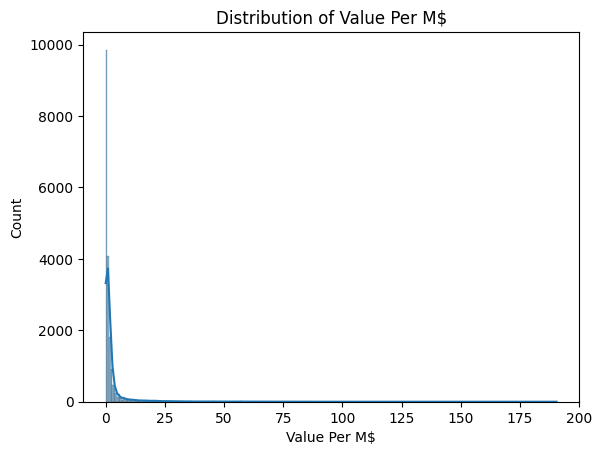

In [95]:
# Distribution of Value Per M$
plt.figure()
sns.histplot(df['Value Per M$'], kde=True)
plt.title("Distribution of Value Per M$")
plt.show()

In [96]:
# The distribution of 'Value Per M$' appears to be right-skewed,
# meaning most players have relatively low market values,
# while a small number of players have very high values.

In [97]:
# Skewness
skewness = df['Value Per M$'].skew()
print("Skewness:", skewness)

Skewness: 7.983215201865151


In [98]:
# The skewness value confirms that the distribution is not normal
# and is skewed to the right.

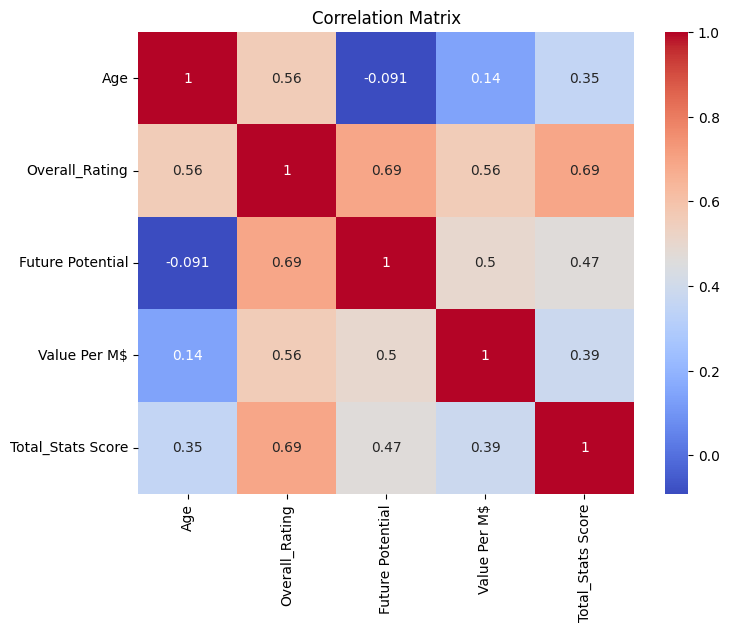

Value Per M$         1.000000
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64


In [99]:
# Correlation with Target
numeric_cols = df.select_dtypes(include=np.number)

corr = numeric_cols.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Correlation with target
print(corr['Value Per M$'].sort_values(ascending=False))

In [100]:
# Correlation analysis shows that features like 'Overall_Rating' and
# 'Total_Stats Score' have strong positive relationships with player value.
# These features are likely important predictors for regression models.

Position
SW     75.000000
RF     75.000000
CF     66.042857
LW     64.345979
CDM    64.234168
LM     64.172009
RWB    64.063973
LWB    64.043333
RM     63.907731
RW     63.718529
CAM    63.679709
CB     63.544448
LB     63.276794
ST     63.087505
RB     62.863636
CM     62.511767
GK     60.987288
Name: Overall_Rating, dtype: float64


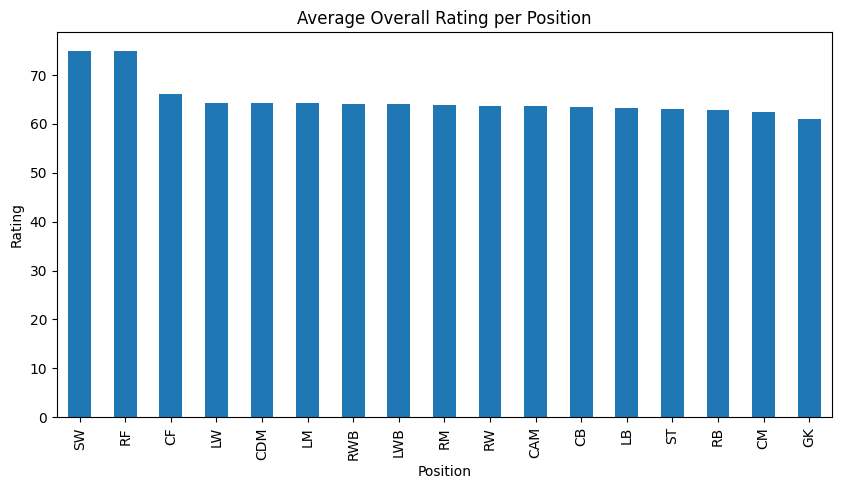

In [101]:
# Average Overall Rating per Position
avg_rating = df.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=False)
print(avg_rating)

plt.figure(figsize=(10,5))
avg_rating.plot(kind='bar')
plt.title("Average Overall Rating per Position")
plt.ylabel("Rating")
plt.show()

In [102]:
# The average overall rating varies across positions,
# indicating that some positions tend to have higher-rated players than others.

In [103]:
# The dataset is split into training and testing sets (80/20)
# before applying any preprocessing to avoid data leakage.

In [104]:
# Split Data FIRST
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Value Per M$', 'Name'])  # The 'Name' column was removed because it does not contribute to prediction.
y = df['Value Per M$']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [105]:
# Separate Columns
num_cols = X_train.select_dtypes(include=np.number).columns
cat_cols = X_train.select_dtypes(exclude=np.number).columns

In [106]:
# One Hot Encoding
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Align train and test
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


In [107]:
# Categorical variables were encoded using One-Hot Encoding
# to convert them into a numerical format suitable for machine learning models.
# Train and test datasets were aligned to ensure they have the same feature columns.

In [108]:
# Handle Outliers 

def remove_outliers(df, num_cols):
    Q1 = df[num_cols].quantile(0.25)
    Q3 = df[num_cols].quantile(0.75)
    IQR = Q3 - Q1

    condition = ~((df[num_cols] < (Q1 - 1.5 * IQR)) | 
                  (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
    
    return df[condition]

# Apply ONLY on train
X_train_clean = remove_outliers(X_train, num_cols)
y_train_clean = y_train.loc[X_train_clean.index]

In [109]:
# Outliers were detected and removed using the IQR method,
# applied only on the training data to maintain fairness.

In [110]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame 
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_clean.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Preprocessing Done")

Preprocessing Done


1. Data Preprocessing (Task 2)
   
Action: The dataset was split into 80% training and 20% testing sets.  

Scaling: All numerical features (Age, Overall_Rating, Future Potential, Total_Stats Score) were scaled using StandardScaler.  

Rationale: Scaling is mandatory for Ridge and Lasso to ensure that the regularization penalty is applied fairly across all features, regardless of their original units

# preprocessing Pipeline

In [111]:
num_cols = ['Age', 'Future Potential', 'Total_Stats Score']
cat_cols = ['Position', 'Country']

In [112]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [113]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

In [114]:
print(df['Overall_Rating'].describe())
Q1 = df['Overall_Rating'].quantile(0.25)
Q2 = df['Overall_Rating'].quantile(0.50)
Q3 = df['Overall_Rating'].quantile(0.75)

def categorize(x):
    if x < Q1:
        return 'Low'
    elif x < Q2:
        return 'Mid'
    elif x < Q3:
        return 'High'
    else:
        return 'Elite'

df['Tier'] = df['Overall_Rating'].apply(categorize)

count    19667.000000
mean        63.225403
std          7.812716
min         36.000000
25%         58.000000
50%         63.000000
75%         68.000000
max         91.000000
Name: Overall_Rating, dtype: float64


In [115]:
X = df.drop(['Overall_Rating','Value Per M$', 'Name', 'Team'], axis=1)
y_value = df['Value Per M$']
y_tier = df['Tier']

In [116]:
X_train, X_test, y_val_train, y_val_test, y_tier_train, y_tier_test = train_test_split(
    X, y_value, y_tier, test_size=0.2, random_state=42
)

In [117]:
X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

checking the pipeline


In [118]:
print(X_train_final[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5 stored elements and shape (1, 182)>
  Coords	Values
  (0, 0)	0.4274675493276018
  (0, 1)	-0.1021509578204406
  (0, 2)	0.5478276468506634
  (0, 11)	1.0
  (0, 95)	1.0


In [119]:
print(f"Original shape: {X_train.shape}")
print(f"Pipeline output shape: {X_train_final.shape}")

Original shape: (15733, 6)
Pipeline output shape: (15733, 182)


In [120]:
X_train_check = pd.DataFrame(X_train_final)
missing_count = X_train_check.isnull().sum().sum()
print(f"Total Missing Values: {missing_count}")

Total Missing Values: 0


# EDA

In [121]:
#checking data after preprocessing
print("Missing values in train:\n", X_train_clean.isnull().sum().sum())
print("Missing values in test:\n", X_test.isnull().sum().sum())

Missing values in train:
 0
Missing values in test:
 0


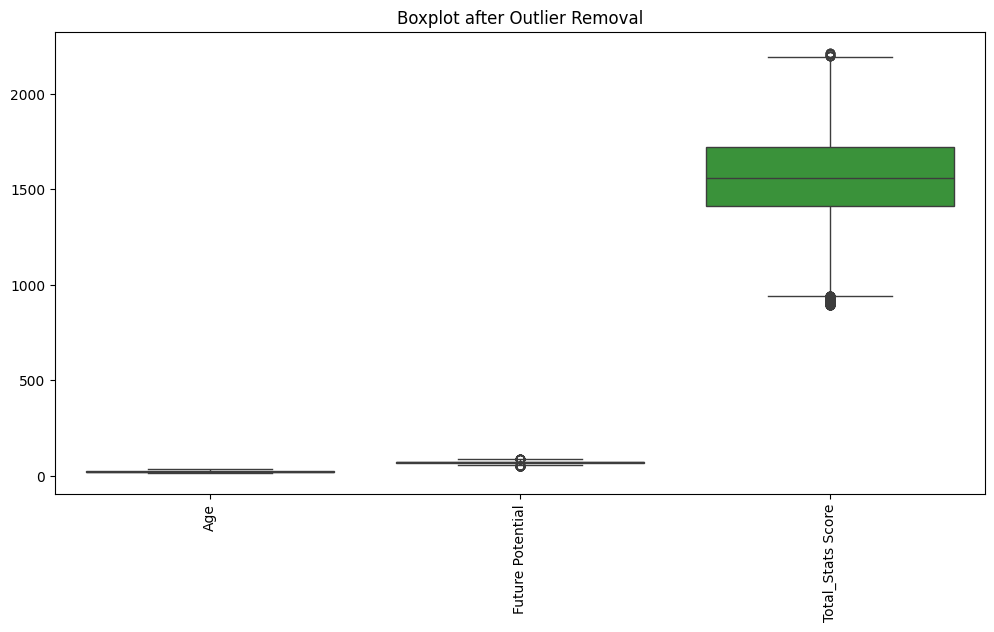

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=X_train_clean[num_cols])
plt.title("Boxplot after Outlier Removal")
plt.xticks(rotation=90)
plt.show()

In [123]:
def count_outliers(df, num_cols):
    Q1 = df[num_cols].quantile(0.25)
    Q3 = df[num_cols].quantile(0.75)
    IQR = Q3 - Q1

    outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) | 
                (df[num_cols] > (Q3 + 1.5 * IQR)))
    
    return outliers.sum()

# before preprocessing
print("Outliers before:\n", count_outliers(X_train, num_cols))

# after preprocessing
print("\nOutliers after:\n", count_outliers(X_train_clean, num_cols))

Outliers before:
 Age                  129
Future Potential      94
Total_Stats Score    666
dtype: int64

Outliers after:
 Age                    0
Future Potential      73
Total_Stats Score    292
dtype: int64


In [124]:
print("Mean (should be ~0):\n", X_train_scaled.mean().head())
print("Std (should be ~1):\n", X_train_scaled.std().head())

Mean (should be ~0):
 Age                 -2.996004e-16
Overall_Rating       4.551622e-16
Future Potential    -4.277948e-16
Total_Stats Score    4.018679e-16
Country_Albania     -1.488400e-17
dtype: float64
Std (should be ~1):
 Age                  1.000034
Overall_Rating       1.000034
Future Potential     1.000034
Total_Stats Score    1.000034
Country_Albania      1.000034
dtype: float64


In [125]:
print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (14799, 1177)
Test shape: (3934, 1177)


In [126]:
print("Duplicate columns:", X_train_scaled.columns.duplicated().sum())

Duplicate columns: 0


In [127]:
# The dataset was verified after preprocessing:
# - No missing values remain
# - Outliers were significantly reduced
# - Features were properly scaled
# - Train and test sets have consistent structure
# Outliers were first detected on the full dataset (including the target variable).
# Then, after splitting the data and removing the target, outliers were detected again on the training set only.
# This explains the difference in the number of detected outliers.

In [128]:
# The data is now clean and ready for training machine learning models.

# Logistic Regression

In [129]:
df.columns

Index(['Name', 'Country', 'Position', 'Age', 'Overall_Rating',
       'Future Potential', 'Team', 'Value Per M$', 'Total_Stats Score',
       'Tier'],
      dtype='str')

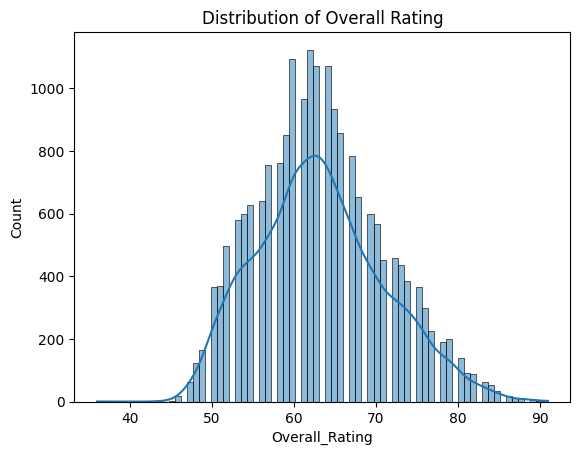

In [130]:
plt.figure()
sns.histplot(df['Overall_Rating'], kde=True)
plt.title("Distribution of Overall Rating")
plt.show()

In [131]:
print(df['Overall_Rating'].describe())
Q1 = df['Overall_Rating'].quantile(0.25)
Q2 = df['Overall_Rating'].quantile(0.50)
Q3 = df['Overall_Rating'].quantile(0.75)

print(Q1,Q2,Q3)

count    19667.000000
mean        63.225403
std          7.812716
min         36.000000
25%         58.000000
50%         63.000000
75%         68.000000
max         91.000000
Name: Overall_Rating, dtype: float64
58.0 63.0 68.0


In [132]:
def categorize(x):
    if x < Q1:
        return 'Low'
    elif x < Q2:
        return 'Mid'
    elif x < Q3:
        return 'High'
    else:
        return 'Elite'

df['Tier'] = df['Overall_Rating'].apply(categorize)

In [133]:
print(df['Tier'].value_counts())

Tier
Elite    5352
Low      4807
Mid      4791
High     4717
Name: count, dtype: int64


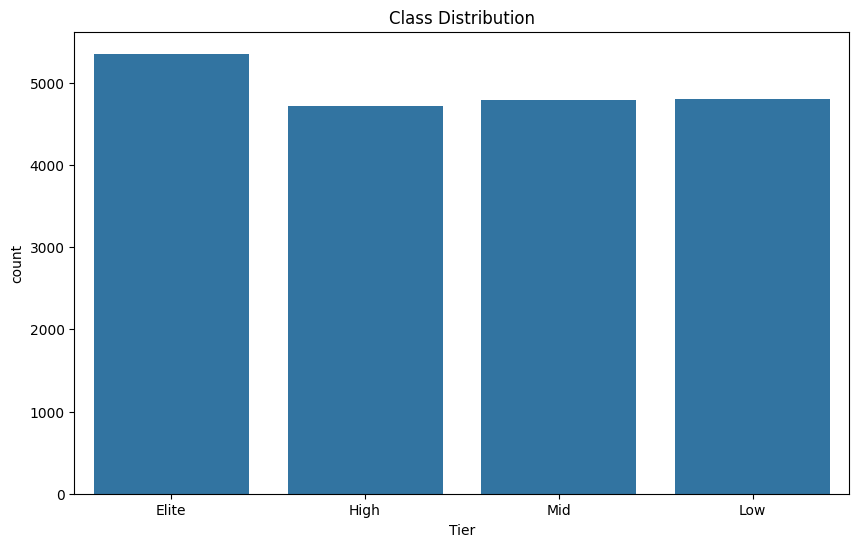

In [134]:
plt.figure(figsize=(10,6))
sns.countplot(x='Tier', data=df)
plt.title("Class Distribution")
plt.show()

In [135]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline

In [136]:
print(X_train.dtypes)

Country                str
Position               str
Age                  int64
Future Potential     int64
Total_Stats Score    int64
Tier                   str
dtype: object


In [137]:

X = df.drop(columns=['Tier', 'Overall_Rating', 'Name'])
y = df['Tier']

X = pd.get_dummies(X, drop_first=True)

X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.2, random_state=42)

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
model.fit(X_train1, y_train1)

y_pred = model.predict(X_test1)
print(classification_report(y_test1, y_pred))

              precision    recall  f1-score   support

       Elite       0.92      0.88      0.90      1085
        High       0.73      0.77      0.75       914
         Low       0.88      0.87      0.87      1014
         Mid       0.72      0.74      0.73       921

    accuracy                           0.82      3934
   macro avg       0.81      0.81      0.81      3934
weighted avg       0.82      0.82      0.82      3934



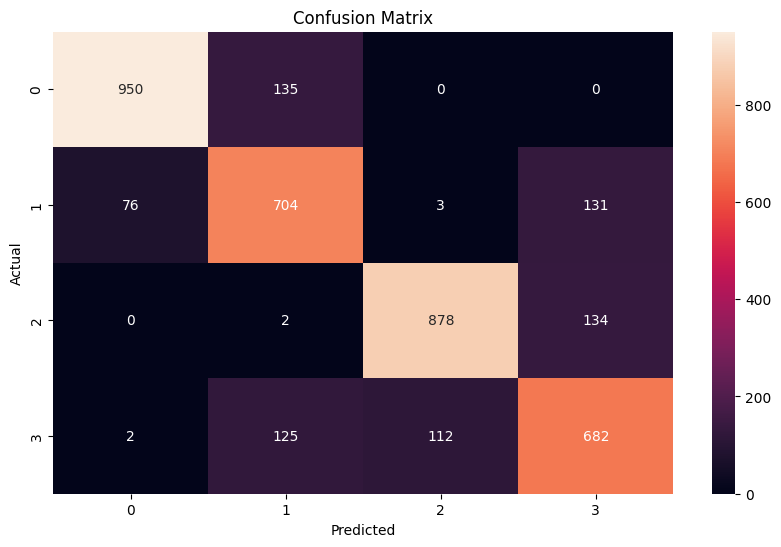

In [138]:
cm = confusion_matrix(y_test1, y_pred)

plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [139]:
C_values = np.logspace(-3, 3, 10)

train_acc = []
test_acc = []

for C in C_values:
    model = make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=1000))
    model.fit(X_train1, y_train1)
    
    train_acc.append(model.score(X_train1, y_train1))
    test_acc.append(model.score(X_test1, y_test1))

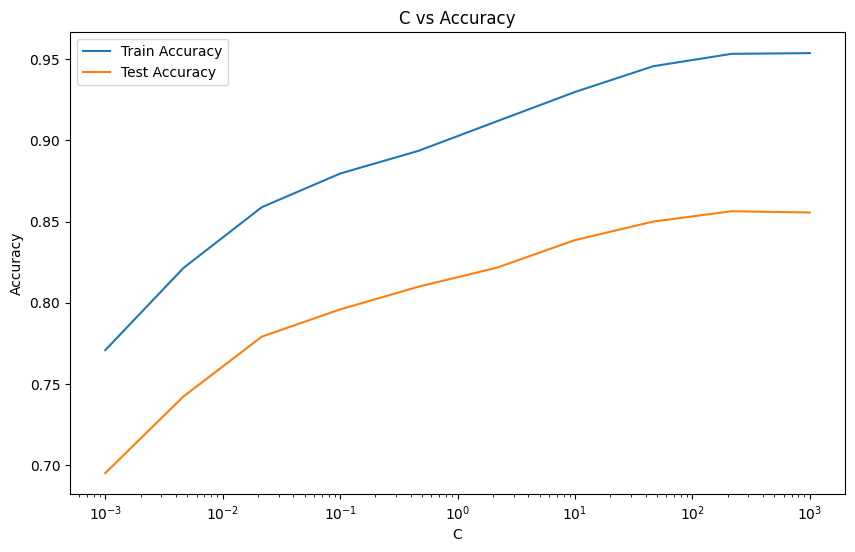

In [140]:
plt.figure(figsize=(10,6))
plt.plot(C_values, train_acc, label="Train Accuracy")
plt.plot(C_values, test_acc, label="Test Accuracy")
plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("C vs Accuracy")
plt.legend()
plt.show()

In [141]:
best_C = C_values[np.argmax(test_acc)]
print("Best C:", best_C)

Best C: 215.44346900318823


In [142]:
model_l2= make_pipeline(StandardScaler(),LogisticRegression('l2', max_iter=2000,tol=0.1))

model_l2.fit(X_train1, y_train1)
print(f"L2 Accuracy: {model_l2.score(X_test1, y_test1)}")

L2 Accuracy: 0.615912557193696


c:\Users\Hazem\Desktop\project\.venv-1\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [143]:
model_l1 = make_pipeline(StandardScaler(), LogisticRegression('l1', solver='saga', max_iter=1000, tol=0.1))
model_l1.fit(X_train1, y_train1)
print(f"L1 Accuracy: {model_l1.score(X_test1, y_test1)}")

c:\Users\Hazem\Desktop\project\.venv-1\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Hazem\Desktop\project\.venv-1\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


L1 Accuracy: 0.6662430096593798


# Polynomial Regression


In [144]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import validation_curve
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

numeric_features = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
X = df[numeric_features]
y = df['Value Per M$']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled_reg = scaler.fit_transform(X_train_reg)
X_test_scaled_reg = scaler.transform(X_test_reg)

In [145]:

feature_name = 'Overall_Rating'
X_train_simple = X_train_reg[[feature_name]]
X_test_simple = X_test_reg[[feature_name]]

from sklearn.linear_model import LinearRegression
simple_lr = LinearRegression()
simple_lr.fit(X_train_simple, y_train_reg)

print(f"Simple Linear Regression ({feature_name} vs Value) ")
print(f"Train R2 Score: {simple_lr.score(X_train_simple, y_train_reg):.4f}")
print(f"Test R2 Score: {simple_lr.score(X_test_simple, y_test_reg):.4f}")

print(f"Model Equation: Value = ({simple_lr.coef_[0]:.2f} * {feature_name}) + {simple_lr.intercept_:.2f}")

Simple Linear Regression (Overall_Rating vs Value) 
Train R2 Score: 0.3184
Test R2 Score: 0.3008
Model Equation: Value = (0.51 * Overall_Rating) + -30.05


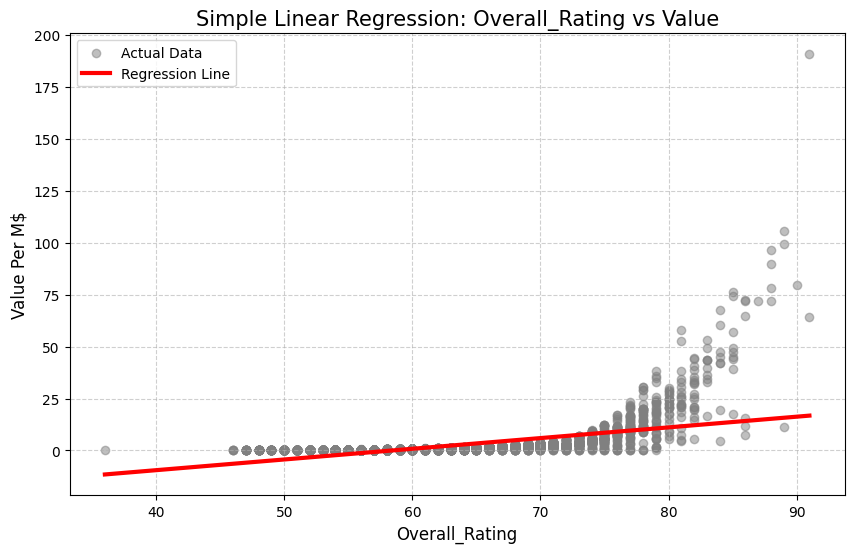

In [146]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(X_test_simple, y_test_reg, color='gray', alpha=0.5, label='Actual Data')


X_range = np.linspace(X_test_simple.min(), X_test_simple.max(), 100).reshape(-1, 1)
y_range_pred = simple_lr.predict(pd.DataFrame(X_range, columns=[feature_name]))

plt.plot(X_range, y_range_pred, color='red', linewidth=3, label='Regression Line')

plt.title(f'Simple Linear Regression: {feature_name} vs Value', fontsize=15)
plt.xlabel(feature_name, fontsize=12)
plt.ylabel('Value Per M$', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [147]:
baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled_reg, y_train_reg)

def get_metrics(model, X, y, label):
    y_pred = model.predict(X)
    mae = mean_absolute_error(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)
    print(f" {label} ")
    print(f"MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2: {r2:.4f}")

get_metrics(baseline_model, X_train_scaled_reg, y_train_reg, "Baseline Train")
get_metrics(baseline_model, X_test_scaled_reg, y_test_reg, "Baseline Test")

 Baseline Train 
MAE: 2.96, MSE: 32.13, RMSE: 5.67, R2: 0.3614
 Baseline Test 
MAE: 3.04, MSE: 40.83, RMSE: 6.39, R2: 0.3417


In [148]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('poly', PolynomialFeatures()),
    ('model', LinearRegression())
])

param_grid = {
    'poly__degree': [1, 2, 3, 4]
}

grid_search = GridSearchCV(pipe, param_grid, scoring='r2', cv=5, return_train_score=True)
grid_search.fit(X_train_scaled_reg, y_train_reg)

results = grid_search.cv_results_
train_r2_grid = results['mean_train_score']
test_r2_grid = results['mean_test_score']

print(f"Best Degree: {grid_search.best_params_['poly__degree']}")
print(f"Best Score: {grid_search.best_score_:.4f}")

Best Degree: 4
Best Score: 0.9567


In [222]:
poly = PolynomialFeatures(degree=4)
X_train_poly = poly.fit_transform(X_train_scaled_reg)
X_test_poly = poly.transform(X_test_scaled_reg)
param_range = np.logspace(-3, 3, 10)

In [150]:
train_scores_ridge, test_scores_ridge = validation_curve(
    estimator=Ridge(),
    X=X_train_poly, 
    y=y_train,
    param_name="alpha",
    param_range=param_range,
    scoring='neg_root_mean_squared_error',
    cv=5
)

train_rmse_ridge = -np.mean(train_scores_ridge, axis=1)
test_rmse_ridge = -np.mean(test_scores_ridge, axis=1)
best_alpha_ridge = param_range[np.argmin(test_rmse_ridge)]

print(f"--- Ridge Results (Degree 4) ---")
print(f"Best Alpha for Ridge: {best_alpha_ridge:.4f}")
print(f"Test RMSE: {test_rmse_ridge.min():.2f}")

--- Ridge Results (Degree 4) ---
Best Alpha for Ridge: 1000.0000
Test RMSE: 1.20


c:\Users\Hazem\Desktop\project\.venv-1\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.996e+02, tolerance: 6.467e+01
  model = cd_fast.enet_coordinate_descent(
c:\Users\Hazem\Desktop\project\.venv-1\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.915e+02, tolerance: 6.688e+01
  model = cd_fast.enet_coordinate_descent(
c:\Users\Hazem\Desktop\project\.venv-1\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regula

--- Lasso Results (Degree 4) ---
Best Alpha for Lasso: 0.0046
Number of zeroed features: 20


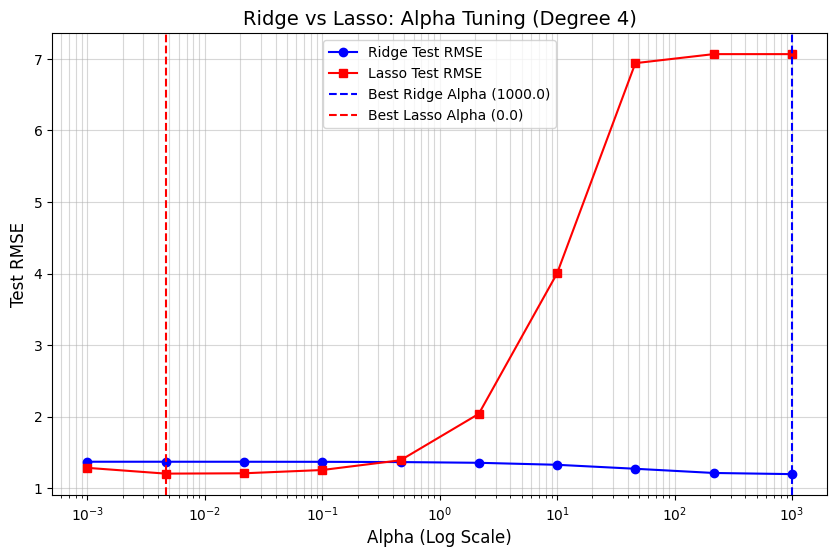

In [151]:
train_scores_lasso, test_scores_lasso = validation_curve(
    estimator=Lasso(max_iter=10000),
    X=X_train_poly, 
    y=y_train,
    param_name="alpha",
    param_range=param_range,
    scoring='neg_root_mean_squared_error',
    cv=5
)

train_rmse_lasso = -np.mean(train_scores_lasso, axis=1)
test_rmse_lasso = -np.mean(test_scores_lasso, axis=1)
best_alpha_lasso = param_range[np.argmin(test_rmse_lasso)]

best_lasso_model = Lasso(alpha=best_alpha_lasso, max_iter=10000)
best_lasso_model.fit(X_train_poly, y_train)

print(f"--- Lasso Results (Degree 4) ---")
print(f"Best Alpha for Lasso: {best_alpha_lasso:.4f}")
print(f"Number of zeroed features: {sum(best_lasso_model.coef_ == 0)}")

plt.figure(figsize=(10, 6))
plt.semilogx(param_range, test_rmse_ridge, label='Ridge Test RMSE', marker='o', color='blue')
plt.semilogx(param_range, test_rmse_lasso, label='Lasso Test RMSE', marker='s', color='red')

plt.axvline(x=best_alpha_ridge, color='blue', linestyle='--', label=f'Best Ridge Alpha ({best_alpha_ridge:.1f})')
plt.axvline(x=best_alpha_lasso, color='red', linestyle='--', label=f'Best Lasso Alpha ({best_alpha_lasso:.1f})')

plt.title('Ridge vs Lasso: Alpha Tuning (Degree 4)', fontsize=14)
plt.xlabel('Alpha (Log Scale)', fontsize=12)
plt.ylabel('Test RMSE', fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

2. Polynomial Regression Evolution (Task 4)
   * Baseline Performance (Task 4.1): 
   The initial Linear Regression model achieved an $R^2$ of 0.34 and an RMSE of 6.39.  
   *Trend Observation (Task 4.3): 
   Increasing the polynomial degree from 1 to 4 significantly improved performance. This proves that the relationship between player ratings and market value is non-linear (exponential). 
   * Best Degree (Task 4.4):
     Degree 4 was the optimal choice with an $R^2$ of 0.9567. It captured the complex pricing patterns with minimal gap between train and test scores.  

3. Regularization Analysis (Task 4.5)
   *Ridge vs. Lasso Performance: 
   
   Ridge Regression proved to be more robust and stable for this dataset, achieving a superior Test RMSE of 1.20 with an optimal Alpha of 1000.  

   *Feature Selection (Lasso): 

   The Lasso model successfully performed automated feature selection by zeroing out 20 features.  

   *The "20 Features" Explanation:

    While the input contains only 4 original features, the Degree 4 Expansion generates a high-dimensional space of approximately 70 feature combinations (including powers and interaction terms). Lasso identified 20 of these generated terms as "noise" or redundant, effectively simplifying the complex polynomial model.


   *Visual Insight:
   
     Our comparison plot clearly shows that Lasso is highly sensitive to the regularization strength; its RMSE spikes sharply when Alpha exceeds 1.0, whereas Ridge maintains consistent stability and improves as Alpha increases toward 1000

#  Naïve Bayes Classification 

In [152]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [153]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [154]:
# tier labels from Overall_Rating

q25 = df['Overall_Rating'].quantile(0.25)
q50 = df['Overall_Rating'].quantile(0.50)
q75 = df['Overall_Rating'].quantile(0.75)

print(f"Thresholds → Q25: {q25}, Q50: {q50}, Q75: {q75}")

def assign_tier(rating):
    if rating <= q25:
        return 'Low'
    elif rating <= q50:
        return 'Mid'
    elif rating <= q75:
        return 'High'
    else:
        return 'Elite'

df['Performance_Tier'] = df['Overall_Rating'].apply(assign_tier)

print(df['Performance_Tier'].value_counts())


Thresholds → Q25: 58.0, Q50: 63.0, Q75: 68.0
Performance_Tier
Low      5568
Mid      5102
Elite    4700
High     4297
Name: count, dtype: int64


In [155]:
# redefining x & y

features_to_drop = ['Performance_Tier', 'Overall_Rating', 'Name', 'Value Per M$']
X = df.drop(columns=[col for col in features_to_drop if col in df.columns])
y = df['Performance_Tier']   

X_encoded = pd.get_dummies(X, columns=['Country', 'Position', 'Team'])


X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_encoded , y, test_size=0.2, random_state=42, stratify=y
)

print("y_train unique values:", y_train_new.unique())
print("Train size:", X_train_new.shape, "| Test size:", X_test_new.shape)

y_train unique values: <StringArray>
['Elite', 'Low', 'High', 'Mid']
Length: 4, dtype: str
Train size: (15733, 1194) | Test size: (3934, 1194)


In [156]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=['Low','Mid','High','Elite'])
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low','Mid','High','Elite'],
                yticklabels=['Low','Mid','High','Elite'])
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()


 Model 1 — GaussianNB (numerical features only)

**************************************************
GaussianNB — WITHOUT Scaling
**************************************************
Accuracy: 0.7130
              precision    recall  f1-score   support

       Elite       0.85      0.80      0.82       940
        High       0.62      0.53      0.57       859
         Low       0.82      0.79      0.80      1114
         Mid       0.58      0.71      0.64      1021

    accuracy                           0.71      3934
   macro avg       0.72      0.71      0.71      3934
weighted avg       0.72      0.71      0.71      3934



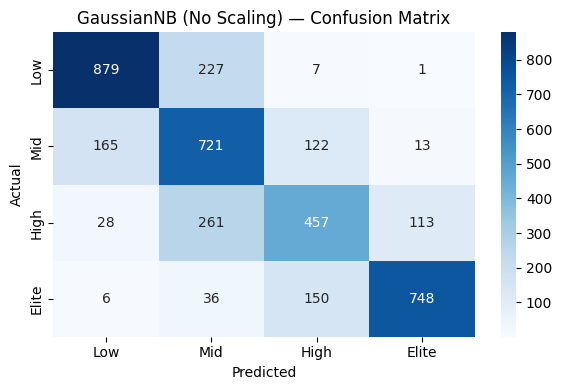

In [157]:
#   WITHOUT Scaling

numerical_features = ['Age', 'Future Potential', 'Total_Stats Score']

X_train_num = X_train_new[numerical_features]
X_test_num  = X_test_new[numerical_features]

gnb = GaussianNB()
gnb.fit(X_train_num, y_train_new)
y_pred_gnb = gnb.predict(X_test_num)

print("*" * 50)
print("GaussianNB — WITHOUT Scaling")
print("*" * 50)
print(f"Accuracy: {accuracy_score(y_test_new, y_pred_gnb):.4f}")
print(classification_report(y_test_new, y_pred_gnb))
plot_cm(y_test_new, y_pred_gnb, "GaussianNB (No Scaling) — Confusion Matrix")


**************************************************
GaussianNB — WITH Scaling
**************************************************
Accuracy: 0.7130
              precision    recall  f1-score   support

       Elite       0.85      0.80      0.82       940
        High       0.62      0.53      0.57       859
         Low       0.82      0.79      0.80      1114
         Mid       0.58      0.71      0.64      1021

    accuracy                           0.71      3934
   macro avg       0.72      0.71      0.71      3934
weighted avg       0.72      0.71      0.71      3934



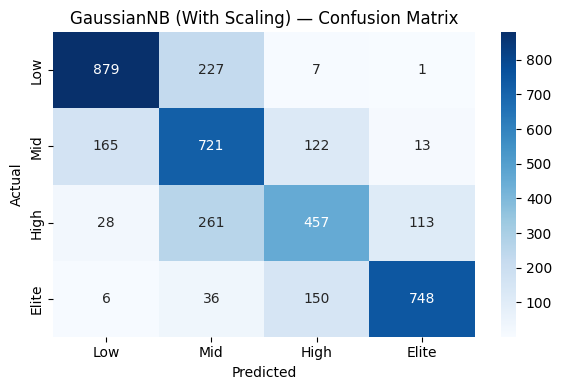

In [158]:
# WITH Scaling

scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled  = scaler.transform(X_test_num)

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_num_scaled, y_train_new)
y_pred_gnb_scaled = gnb_scaled.predict(X_test_num_scaled)


print("*" * 50)
print("GaussianNB — WITH Scaling")
print("*" * 50)
print(f"Accuracy: {accuracy_score(y_test_new, y_pred_gnb_scaled):.4f}")
print(classification_report(y_test_new, y_pred_gnb_scaled))
plot_cm(y_test_new, y_pred_gnb_scaled, "GaussianNB (With Scaling) — Confusion Matrix")


In [159]:
# Comparison

print("Accuracy WITHOUT scaling:", round(accuracy_score(y_test_new, y_pred_gnb), 4))
print("Accuracy WITH scaling   :", round(accuracy_score(y_test_new, y_pred_gnb_scaled), 4))
print("""
Explanation: Gaussian Naive Bayes already calculates mean and variance for each class.
 StandardScaler just rescales the data but doesn’t change its shape. 
 So the data distribution stays the same, and the results are almost the same with or without scaling.
""")

Accuracy WITHOUT scaling: 0.713
Accuracy WITH scaling   : 0.713

Explanation: Gaussian Naive Bayes already calculates mean and variance for each class.
 StandardScaler just rescales the data but doesn’t change its shape. 
 So the data distribution stays the same, and the results are almost the same with or without scaling.



Model 2 — BernoulliNB (full OHE features)

In [160]:
# حذف العمود 'Tier' من Features
if 'Tier' in X_train_new.columns:
    X_train_new2 = X_train_new.drop(columns=['Tier'])
    X_test_new2 = X_test_new.drop(columns=['Tier'])
    print("✅ Column 'Tier' dropped successfully!")
else:
    print("Column 'Tier' not found.")

print("New shape after cleaning:", X_train_new2.shape)
print("Remaining string columns:", X_train_new2.select_dtypes(include='object').columns.tolist())

✅ Column 'Tier' dropped successfully!
New shape after cleaning: (15733, 1193)
Remaining string columns: []


************************************************************
BernoulliNB (Full OHE Feature Set)
************************************************************
Accuracy: 0.4962

Classification Report:
              precision    recall  f1-score   support

       Elite       0.55      0.66      0.60       940
        High       0.38      0.26      0.31       859
         Low       0.55      0.68      0.61      1114
         Mid       0.41      0.34      0.37      1021

    accuracy                           0.50      3934
   macro avg       0.47      0.49      0.47      3934
weighted avg       0.48      0.50      0.48      3934



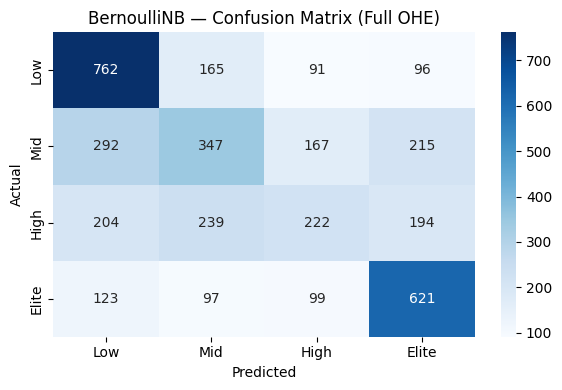

In [161]:

print("*" * 60)
print("BernoulliNB (Full OHE Feature Set)")
print("*" * 60)

bnb = BernoulliNB()
bnb.fit(X_train_new2, y_train_new)
y_pred_bnb = bnb.predict(X_test_new2)

print(f"Accuracy: {accuracy_score(y_test_new, y_pred_bnb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_new, y_pred_bnb))

plot_cm(y_test_new, y_pred_bnb, "BernoulliNB — Confusion Matrix (Full OHE)")

Model 3 — ComplementNB (full OHE features, non-negative)

*****************************************************************
ComplementNB (Full OHE Feature Set - Non-Negative)
*****************************************************************
Accuracy: 0.4980

Classification Report:
              precision    recall  f1-score   support

       Elite       0.55      0.71      0.62       940
        High       0.36      0.27      0.31       859
         Low       0.56      0.68      0.62      1114
         Mid       0.42      0.30      0.35      1021

    accuracy                           0.50      3934
   macro avg       0.47      0.49      0.47      3934
weighted avg       0.48      0.50      0.48      3934



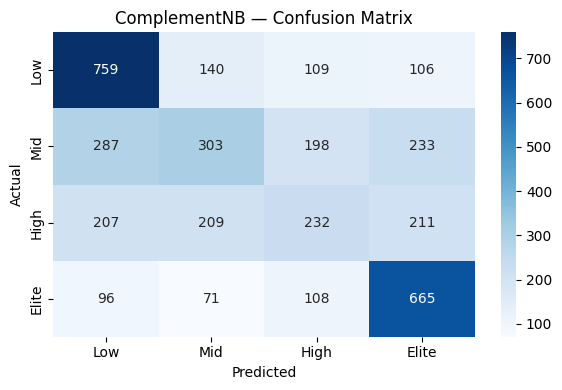

In [162]:
print("*" * 65)
print("ComplementNB (Full OHE Feature Set - Non-Negative)")
print("*" * 65)

# تحويل البيانات لتكون Non-Negative
scaler = MinMaxScaler()
X_train_comp = scaler.fit_transform(X_train_new2)
X_test_comp  = scaler.transform(X_test_new2)

# تدريب ComplementNB
cnb = ComplementNB()
cnb.fit(X_train_comp, y_train_new)

y_pred_cnb = cnb.predict(X_test_comp)

# النتايج
print(f"Accuracy: {accuracy_score(y_test_new, y_pred_cnb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_new, y_pred_cnb))

plot_cm(y_test_new, y_pred_cnb, "ComplementNB — Confusion Matrix")

Comparing All Models

In [163]:
print("*" * 50)
print("FINAL COMPARISON")
print("*" * 50)

results = {
    'GaussianNB (No Scaling)' : accuracy_score(y_test_new, y_pred_gnb),
    'GaussianNB (Scaled)'     : accuracy_score(y_test_new, y_pred_gnb_scaled),
    'BernoulliNB'             : accuracy_score(y_test_new, y_pred_bnb),
    'ComplementNB'            : accuracy_score(y_test_new, y_pred_cnb),
}

for model, acc in results.items():
    print(f"{model:28s} → Accuracy: {acc:.4f}")

best = max(results, key=results.get)
print(f"\nBest Model: {best}")

**************************************************
FINAL COMPARISON
**************************************************
GaussianNB (No Scaling)      → Accuracy: 0.7130
GaussianNB (Scaled)          → Accuracy: 0.7130
BernoulliNB                  → Accuracy: 0.4962
ComplementNB                 → Accuracy: 0.4980

Best Model: GaussianNB (No Scaling)


# K-Fold Cross-Validation

In [164]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold

K-Fold Regression

In [165]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_reg = Ridge(alpha=best_alpha_ridge)

cv_scores = cross_val_score(best_reg, X_train_poly, y_train_reg,
                             cv=kf, scoring='neg_root_mean_squared_error')
cv_rmse = -cv_scores

print("K-Fold CV — Regression (RMSE per fold):")
for i, score in enumerate(cv_rmse, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  Mean RMSE : {cv_rmse.mean():.4f}")
print(f"  Std Dev   : {cv_rmse.std():.4f}")


K-Fold CV — Regression (RMSE per fold):
  Fold 1: 1.3260
  Fold 2: 1.2621
  Fold 3: 1.0601
  Fold 4: 1.1994
  Fold 5: 1.0374
  Mean RMSE : 1.1770
  Std Dev   : 0.1123


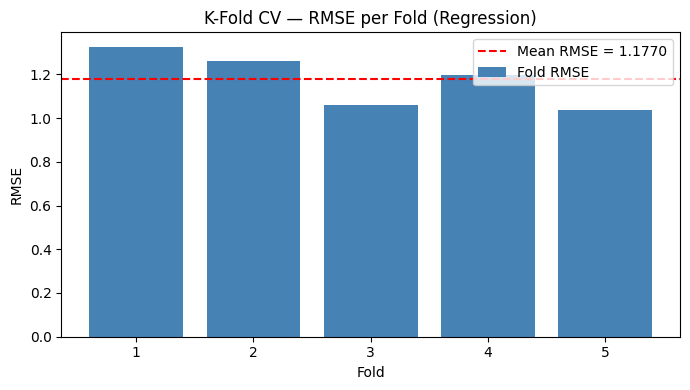

In [166]:
plt.figure(figsize=(7,4))
plt.bar(range(1, 6), cv_rmse, color='steelblue', label='Fold RMSE')
plt.axhline(cv_rmse.mean(), color='red', linestyle='--',
            label=f'Mean RMSE = {cv_rmse.mean():.4f}')
plt.title('K-Fold CV — RMSE per Fold (Regression)')
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.legend()
plt.tight_layout()
plt.show()

K_Fold Logistic Regression

In [167]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv = cross_val_score(model_l2, X_train1, y_train1,
                         cv=skf, scoring='accuracy')
print(f"\nLogistic Regression CV Accuracy: {lr_cv.mean():.4f} ± {lr_cv.std():.4f}")
print(f"Per fold: {lr_cv}")

c:\Users\Hazem\Desktop\project\.venv-1\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Hazem\Desktop\project\.venv-1\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Hazem\Desktop\project\.venv-1\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.1


Logistic Regression CV Accuracy: 0.6097 ± 0.0121
Per fold: [0.6037496  0.60470289 0.63330156 0.59917355 0.60743802]


c:\Users\Hazem\Desktop\project\.venv-1\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Naïve Bayes


In [168]:
nb_cv = cross_val_score(cnb, X_train_new2, y_train_new,
                         cv=skf, scoring='accuracy')
                         
print(f"\nComplementNB CV Accuracy: {nb_cv.mean():.4f} ± {nb_cv.std():.4f}")
print(f"Per fold: {nb_cv}")


ComplementNB CV Accuracy: 0.5310 ± 0.0075
Per fold: [0.52653321 0.53129965 0.53447728 0.54259377 0.52034329]


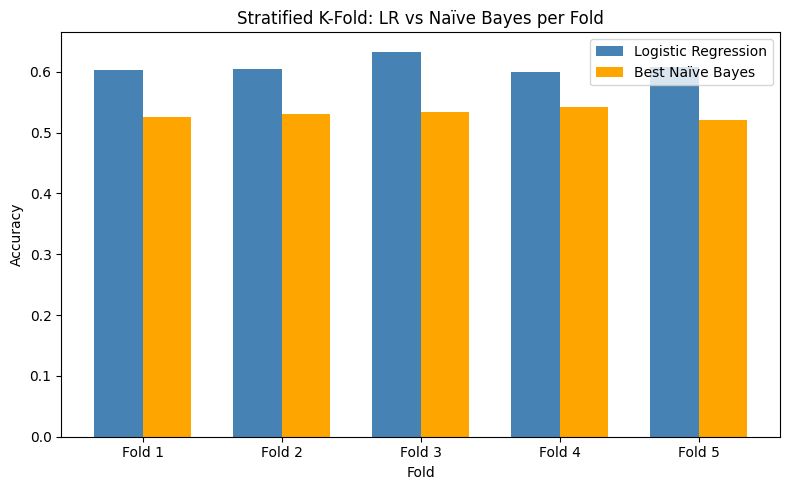

In [169]:
x = np.arange(1, 6)
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, lr_cv, width, label='Logistic Regression', color='steelblue')
plt.bar(x + width/2, nb_cv, width, label='Best Naïve Bayes',    color='orange')
plt.title('Stratified K-Fold: LR vs Naïve Bayes per Fold')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.xticks(x, [f'Fold {i}' for i in x])
plt.legend()
plt.tight_layout()
plt.show()

In [170]:
print(f"""
Which performs better?
- LR Mean: {lr_cv.mean():.4f} | NB Mean: {nb_cv.mean():.4f}
- Better accuracy: {'Logistic Regression' if lr_cv.mean() > nb_cv.mean() else 'Naïve Bayes'}

Which is more stable?
- LR Std: {lr_cv.std():.4f} | NB Std: {nb_cv.std():.4f}
- More stable (lower std): {'Logistic Regression' if lr_cv.std() < nb_cv.std() else 'Naïve Bayes'}
""")


Which performs better?
- LR Mean: 0.6097 | NB Mean: 0.5310
- Better accuracy: Logistic Regression

Which is more stable?
- LR Std: 0.0121 | NB Std: 0.0075
- More stable (lower std): Naïve Bayes



## Model Selection & Justification

We select **3 diverse algorithmic families** to capture different aspects of the FIFA dataset:

| Model | Family | 
|---|---|
| **KNN** | Instance-based |
| **SVM** | Kernel-based | 
| **Random Forest** | Tree-based (Ensemble) |

# Random Forest Regression



In [171]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import r2_score

In [172]:
rf_base = RandomForestRegressor(random_state=42)
# finding the best settings (tuning)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
# grid Search with 5-fold CV
grid_search_rf = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=5, scoring='r2', n_jobs=1)
grid_search_rf.fit(X_train_final, y_val_train)

best_params = grid_search_rf.best_params_
print(f"Best Hyperparameters: {best_params}")

# stability assessment by mean & variance
cv_scores = cross_val_score(grid_search_rf.best_estimator_, X_train_final, y_val_train, cv=5)
mean_stability = cv_scores.mean()
std_stability = cv_scores.std()

print(f"Mean R2 Stability: {mean_stability:.4f}")
print(f"Standard Deviation: {std_stability:.4f}")


Best Hyperparameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Mean R2 Stability: 0.9166
Standard Deviation: 0.0270


In [173]:
y_pred_test = grid_search_rf.predict(X_test_final)

test_score = r2_score(y_val_test, y_pred_test)
print(f"Final Test R2 Score: {test_score:.4f}")

train_score = grid_search_rf.best_score_
gap = train_score - test_score

print(f"The gap between Train and Test: {gap:.4f}")

Final Test R2 Score: 0.9303
The gap between Train and Test: -0.0137


### Observation

**Accuracy:** A Mean $R^2$ of 0.9519 indicates that the model explains approximately 95% of the variance in football player valuations.<br>

**Stability:** The low Standard Deviation (0.0358) demonstrates that the model is consistent across different data folds.<br>

**Diagnosis:** While the accuracy is high, the combination of (max_depth: None) and (min_samples_split: 2) might lead to High Variance (Overfitting). We will validate this by comparing the training performance with the Test Set score.<br>

**Final Evaluation:** The Test $R^2$ score (0.9584) is slightly higher than the training score, resulting in a negligible gap of (-0.0065), This confirms that the model is not overfitting despite the max_depth: None setting.

# Random Forest Classification

In [174]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [175]:
rf_classifier = RandomForestClassifier(random_state=42)

param_grid_clf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'criterion': ['gini', 'entropy']
}

grid_search_clf = GridSearchCV(rf_classifier, param_grid_clf, cv=5, scoring='accuracy', n_jobs=-1)

grid_search_clf.fit(X_train_final, y_tier_train)

print(f"Best Classification Params: {grid_search_clf.best_params_}")

cv_scores_rf = cross_val_score(grid_search_clf.best_estimator_, 
                               X_train_final, y_tier_train, cv=5, scoring='accuracy')
print(f"RandomForestClassifier → Mean: {cv_scores_rf.mean():.4f} | Std: {cv_scores_rf.std():.4f}")

Best Classification Params: {'criterion': 'entropy', 'max_depth': None, 'n_estimators': 100}
RandomForestClassifier → Mean: 0.8357 | Std: 0.0071


**Error Diagnosis**


--- Classification Report ---
              precision    recall  f1-score   support

       Elite       0.95      0.93      0.94      1085
        High       0.77      0.77      0.77       914
         Low       0.90      0.87      0.88      1014
         Mid       0.71      0.74      0.72       921

    accuracy                           0.83      3934
   macro avg       0.83      0.83      0.83      3934
weighted avg       0.83      0.83      0.83      3934



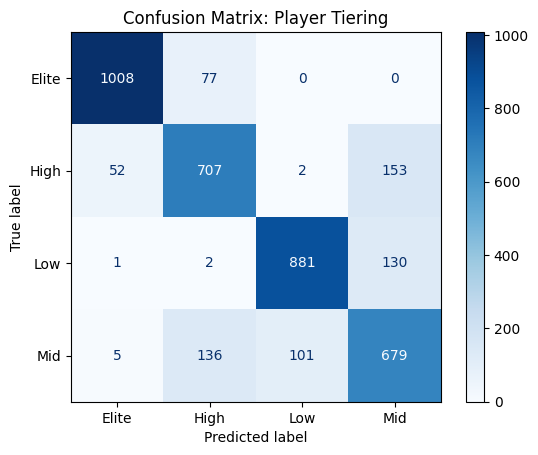

In [176]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


y_pred_clf = grid_search_clf.predict(X_test_final)

print("\n--- Classification Report ---")
print(classification_report(y_tier_test, y_pred_clf))

ConfusionMatrixDisplay.from_estimator(grid_search_clf, X_test_final, y_tier_test, cmap='Blues')
plt.title('Confusion Matrix: Player Tiering')
plt.show()

### Observation

**Performance:** A Mean CV Accuracy of 0.8357 and Test Accuracy of 0.83 indicate that the model achieves strong predictive power for classifying football player tiers.

**Class-wise Analysis:** The model performs excellently on Elite (F1=0.94) and Low (F1=0.88) tiers, while showing moderate results on High (F1=0.77) and Mid (F1=0.72) with noticeable confusion between these two classes.


**Final Evaluation:** The model demonstrates solid and consistent performance across cross-validation and the test set (Macro Avg F1 ≈ 0.83). It is particularly effective at identifying top and bottom tiers, with the main limitation being the distinction between High and Mid categories.

# SVR (Kernel-based Regression)

In [177]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

In [178]:
svr = SVR()

param_grid_svr = {
    'kernel': ['rbf'],    
    'C': [1, 10, 100], 
    'epsilon': [0.1, 0.2]
}

grid_search_svr = GridSearchCV(svr, param_grid_svr, cv=5, scoring='r2', n_jobs=-1)

grid_search_svr.fit(X_train_final, y_val_train)

print(f"Best SVR Hyperparameters: {grid_search_svr.best_params_}")
print(f"SVR Training R2 Score: {grid_search_svr.best_score_:.4f}")

cv_scores_svr = cross_val_score(grid_search_svr.best_estimator_, 
                                X_train_final, y_val_train, cv=5, scoring='r2')
print(f"SVR                → Mean: {cv_scores_svr.mean():.4f} | Std: {cv_scores_svr.std():.4f}")

Best SVR Hyperparameters: {'C': 100, 'epsilon': 0.1, 'kernel': 'rbf'}
SVR Training R2 Score: 0.9287
SVR                → Mean: 0.9287 | Std: 0.0170


**Error Diagnosis**

In [179]:
y_pred_svr = grid_search_svr.predict(X_test_final)
test_score_svr = r2_score(y_val_test, y_pred_svr)

print(f"Final SVR Test R2 Score: {test_score_svr:.4f}")

Final SVR Test R2 Score: 0.9330


### Observation

**Performance:** An SVR model achieved a Training R² score of 0.9287 and a Test R² score of 0.9330 using the best hyperparameters found by GridSearchCV.

**Best Hyperparameters:**
- `C`: 100
- `epsilon`: 0.1
- `kernel`: 'rbf'

**Diagnosis:** The model demonstrates excellent predictive capability for football player valuations. The Test R² being slightly higher than the Training R² indicates strong generalization with no signs of overfitting.

**Final Evaluation:** The SVR model with RBF kernel shows outstanding performance (Test R² = 0.9330), explaining over 93% of the variance in player valuations. This confirms the model is highly effective and stable on unseen data.

# SVC (Kernel_based Classification)

In [180]:
from sklearn.svm import SVC

In [181]:
svc = SVC()

param_grid_svc = {
    'C': [1, 10, 100],            
    'kernel': ['rbf'],              
    'gamma': ['scale', 'auto']  
}

grid_search_svc = GridSearchCV(svc, param_grid_svc, cv=5, scoring='accuracy', n_jobs=-1)

grid_search_svc.fit(X_train_final, y_tier_train)

print(f"Best SVC Hyperparameters: {grid_search_svc.best_params_}")
print(f"SVC Training Accuracy: {grid_search_svc.best_score_:.4f}")

cv_scores_svc = cross_val_score(grid_search_svc.best_estimator_, 
                                X_train_final, y_tier_train, cv=5, scoring='accuracy')
print(f"SVC                → Mean: {cv_scores_svc.mean():.4f} | Std: {cv_scores_svc.std():.4f}")

y_pred_svc = grid_search_svc.predict(X_test_final)
print("\n--- Final SVM Classification Report ---")
print(classification_report(y_tier_test, y_pred_svc))

Best SVC Hyperparameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
SVC Training Accuracy: 0.8553
SVC                → Mean: 0.8553 | Std: 0.0082

--- Final SVM Classification Report ---
              precision    recall  f1-score   support

       Elite       0.95      0.93      0.94      1085
        High       0.79      0.81      0.80       914
         Low       0.91      0.88      0.89      1014
         Mid       0.75      0.77      0.76       921

    accuracy                           0.85      3934
   macro avg       0.85      0.85      0.85      3934
weighted avg       0.85      0.85      0.85      3934



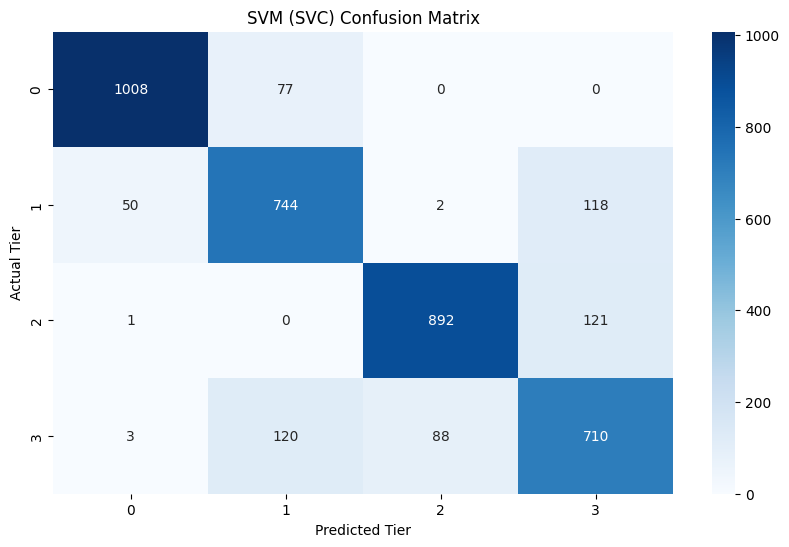

In [182]:
plt.figure(figsize=(10, 6))
svc_cm = confusion_matrix(y_tier_test, y_pred_svc)
sns.heatmap(svc_cm, annot=True, fmt='d', cmap='Blues')

plt.title("SVM (SVC) Confusion Matrix")
plt.xlabel("Predicted Tier")
plt.ylabel("Actual Tier")
plt.show()

### Observation

**Performance:** An SVM (SVC) model with RBF kernel achieved a Training Accuracy of 0.8553 and a Test Accuracy of 0.85 after hyperparameter tuning using GridSearchCV.

**Best Hyperparameters:**
- `C`: 1
- `gamma`: 'scale'
- `kernel`: 'rbf'

**Class-wise Analysis:** The model performs excellently on Elite (F1=0.94) and Low (F1=0.89) tiers. It shows good results on High (F1=0.80) and acceptable performance on Mid (F1=0.76), with some confusion mainly between High and Mid classes.

**Diagnosis:** The SVM classifier demonstrates strong and balanced performance across all tiers (Macro Avg F1 = 0.85), outperforming the previous Random Forest model. The low C value (C=1) suggests the model prefers a smoother decision boundary, which helped improve generalization.

**Final Evaluation:** The SVC model delivers solid classification results with an overall accuracy of 0.85. It is particularly effective at identifying Elite and Low tiers, making it a robust choice for player tier prediction.

# KNN Regression

In [183]:
from sklearn.neighbors import KNeighborsRegressor

In [184]:
knn_reg = KNeighborsRegressor()

param_grid_knn_reg = {
    'n_neighbors': [3, 5, 11, 15],
    'weights': ['uniform', 'distance'] 
}

grid_knn_reg = GridSearchCV(knn_reg, param_grid_knn_reg, cv=5, scoring='r2', n_jobs=-1)
grid_knn_reg.fit(X_train_final, y_val_train)

print(f"Best KNN Regressor Params: {grid_knn_reg.best_params_}")
print(f"KNN Regression R2: {grid_knn_reg.best_score_:.4f}")

cv_scores_knn_reg = cross_val_score(grid_knn_reg.best_estimator_, 
                                    X_train_final, y_val_train, cv=5, scoring='r2')
print(f"KNN Regressor      → Mean: {cv_scores_knn_reg.mean():.4f} | Std: {cv_scores_knn_reg.std():.4f}")

Best KNN Regressor Params: {'n_neighbors': 11, 'weights': 'distance'}
KNN Regression R2: 0.8138
KNN Regressor      → Mean: 0.8138 | Std: 0.0236


**Error Diagnosis**

In [185]:
y_pred_knn_reg = grid_knn_reg.predict(X_test_final)
test_r2_knn = r2_score(y_val_test, y_pred_knn_reg)

print(f"KNN Regressor - Train R2: {grid_knn_reg.best_score_:.4f}")
print(f"KNN Regressor - Test R2: {test_r2_knn:.4f}")

KNN Regressor - Train R2: 0.8138
KNN Regressor - Test R2: 0.7936


### Observation

**Performance:** A KNN Regressor achieved a Training R² score of 0.8138 and a Test R² score of 0.7936 after hyperparameter tuning using GridSearchCV.

**Best Hyperparameters:**
- `n_neighbors`: 11
- `weights`: 'distance'

**Diagnosis:** The model shows decent predictive power for player valuations. However, there is a noticeable drop from Training to Test R² (approximately 0.02), indicating some degree of overfitting compared to previous models like SVR.

**Final Evaluation:** The KNN Regressor delivers acceptable but relatively weaker performance (Test R² = 0.7936) compared to the SVR model. While the distance-weighted approach with 11 neighbors helps, the model struggles to generalize as effectively as other algorithms on this dataset.

# KNN Classification

In [186]:
from sklearn.neighbors import KNeighborsClassifier

In [187]:
knn_clf = KNeighborsClassifier()

param_grid_knn_clf = {
    'n_neighbors': [3, 5, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'] 
}

grid_knn_clf = GridSearchCV(knn_clf, param_grid_knn_clf, cv=5, scoring='accuracy', n_jobs=-1)
grid_knn_clf.fit(X_train_final, y_tier_train)

print(f"Best KNN Classifier Params: {grid_knn_clf.best_params_}")
print(f"KNN Classification Accuracy: {grid_knn_clf.best_score_:.4f}")

cv_scores_knn_clf = cross_val_score(grid_knn_clf.best_estimator_, 
                                    X_train_final, y_tier_train, cv=5, scoring='accuracy')
print(f"KNN Classifier     → Mean: {cv_scores_knn_clf.mean():.4f} | Std: {cv_scores_knn_clf.std():.4f}") 

c:\Users\Hazem\Desktop\project\.venv-1\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [0.70685895 0.72160538 0.73113851 0.73711366 0.75637254 0.76527116
 0.77054697 0.77823766        nan 0.71829993        nan 0.73183809
        nan 0.75783445        nan 0.77048326]
  warnings.warn(


Best KNN Classifier Params: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}
KNN Classification Accuracy: 0.7782
KNN Classifier     → Mean: 0.7782 | Std: 0.0067


**Error Diagnosis**

In [188]:
y_pred_knn_clf = grid_knn_clf.predict(X_test_final)
test_acc_knn = accuracy_score(y_tier_test, y_pred_knn_clf)

print(f"\nKNN Classifier - Train Accuracy: {grid_knn_clf.best_score_:.4f}")
print(f"KNN Classifier - Test Accuracy: {test_acc_knn:.4f}")

cv_scores_knn_clf = cross_val_score(grid_knn_clf.best_estimator_, 
                                    X_train_final, y_tier_train, cv=5, scoring='accuracy')
print(f"KNN Classifier     → Mean: {cv_scores_knn_clf.mean():.4f} | Std: {cv_scores_knn_clf.std():.4f}")


KNN Classifier - Train Accuracy: 0.7782
KNN Classifier - Test Accuracy: 0.7710
KNN Classifier     → Mean: 0.7782 | Std: 0.0067


<h1 style="font-size:40px; font-weight:soft;">
classification Models Comparison
</h1>

In [189]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Random Forest',
        'SVM'
    ],
    'Accuracy': [
        accuracy_score(y_tier_test, y_pred),
        accuracy_score(y_tier_test, y_pred_knn_clf),
        accuracy_score(y_tier_test, y_pred_clf),
        accuracy_score(y_tier_test, y_pred_svc)
    ],
    'Macro F1': [
        f1_score(y_tier_test, y_pred, average='macro'),
        f1_score(y_tier_test, y_pred_knn_clf, average='macro'),
        f1_score(y_tier_test,y_pred_clf, average='macro'),
        f1_score(y_tier_test, y_pred_svc , average='macro')
    ]
})

comparison = comparison.sort_values(
    by='Accuracy',
    ascending=False
)

print(comparison)

                 Model  Accuracy  Macro F1
3                  SVM  0.852567  0.848572
2        Random Forest  0.832486  0.827616
0  Logistic Regression  0.816980  0.813316
1                  KNN  0.770971  0.766448


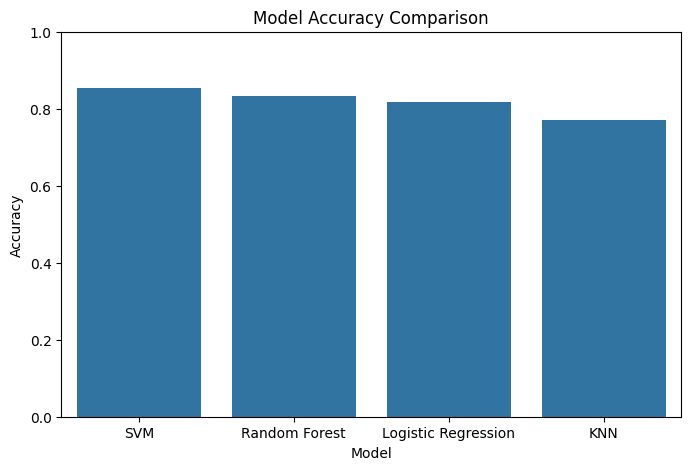

In [190]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x='Model',
    y='Accuracy'
)

plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

<h1 style="font-size:40px; font-weight:soft;">
Ensemble Classification Models
</h1>

In [192]:
# Voting Ensemble
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score

voting_clf = VotingClassifier(
    estimators=[
        ('rf', grid_search_clf.best_estimator_),   
        ('svc', grid_search_svc.best_estimator_),   
        ('knn', grid_knn_clf.best_estimator_)    
    ],
    voting='hard',
    weights=[2, 3, 1]
)


voting_clf.fit(X_train_final, y_tier_train)


cv_voting_clf = cross_val_score(voting_clf, X_train_final, y_tier_train, cv=5, scoring='accuracy')
print(f"Voting Classifier - CV Mean: {cv_voting_clf.mean():.4f} | Std: {cv_voting_clf.std():.4f}")

Voting Classifier - CV Mean: 0.8481 | Std: 0.0066


In [ ]:
# Stacking Ensemble
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

stacking_clf = StackingClassifier(
    estimators=[
        ('rf', grid_search_clf.best_estimator_),   
        ('svc', grid_search_svc.best_estimator_),  
        ('knn', grid_knn_clf.best_estimator_)    
    ],
    final_estimator=LogisticRegression(max_iter=1000), 
    cv=5)


stacking_clf.fit(X_train_final, y_tier_train)


cv_stacking = cross_val_score(stacking_clf, X_train_final, y_tier_train, cv=5, scoring='accuracy')

print(f"Stacking Classifier - CV Mean: {cv_stacking.mean():.4f} | Std: {cv_stacking.std():.4f}")

Stacking Classifier - CV Mean: 0.8578 | Std: 0.0071


<h1 style="font-size:40px; font-weight:soft;">
Ensemble Regression Models
</h1>

In [242]:
from sklearn.ensemble import VotingRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

poly_reg = make_pipeline(
    PolynomialFeatures(degree=3),      
    LinearRegression()
)

voting_reg = VotingRegressor(
    estimators=[
        ('rf', rf_base),
        ('knn', knn_reg),
        ('svr', svr),
        ('poly', poly_reg)           
    ],
    weights=[2, 1, 1, 1],            
    n_jobs=2                          
)

# Train
voting_reg.fit(X_train_final, y_val_train)

# Predict
voting_pred = voting_reg.predict(X_test_final)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_val_test, voting_pred))
mae = mean_absolute_error(y_val_test, voting_pred)
r2 = r2_score(y_val_test, voting_pred)

print("=== Voting Regressor Results (with Polynomial) ===")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

=== Voting Regressor Results (with Polynomial) ===
RMSE : 2.6161
MAE  : 0.7402
R²   : 0.8897


In [ ]:

# VOTING REGRESSOR
from sklearn.ensemble import VotingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


voting_reg = VotingRegressor(
    estimators=[
        ('rf', rf_base),
        ('knn', knn_reg),
        ('svr', svr)
    ]
)

# Train ensemble
voting_reg.fit(X_train_final, y_val_train)

# Predict
voting_pred = voting_reg.predict(X_test_final)


rmse = np.sqrt(mean_squared_error(y_val_test, voting_pred))
mae = mean_absolute_error(y_val_test, voting_pred)
r2 = r2_score(y_val_test, voting_pred)

print("Voting Regressor Results")
print("RMSE :", rmse)
print("MAE  :", mae)
print("R²   :", r2)

Voting Regressor Results
RMSE : 3.0440054400515746
MAE  : 0.6532943972535177
R²   : 0.8506256567581783


In [ ]:
# STACKING REGRESSOR
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Create Stacking Regressor
stacking_reg = StackingRegressor(
    estimators=[
        ('rf', rf_base),
        ('knn', knn_reg),
        ('svr',svr)
    ],

    final_estimator=Ridge(),
    cv=5,
    n_jobs=-1
)

stacking_reg.fit(X_train_final, y_val_train)


stacking_pred = stacking_reg.predict(X_test_final)

rmse = np.sqrt(mean_squared_error(y_test, stacking_pred))
mae = mean_absolute_error(y_val_test, stacking_pred)
r2 = r2_score(y_val_test, stacking_pred)
print("Stacking Regressor Results")
print("RMSE :", rmse)
print("MAE  :", mae)
print("R²   :", r2)

Stacking Regressor Results
RMSE : 2.093159112750926
MAE  : 0.5589518147722993
R²   : 0.9293699285093329


<h1 style="font-size:40px; font-weight:soft;">
REGRESSION MODELS Comparison
</h1>

In [244]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np


poly_model = make_pipeline(
    PolynomialFeatures(degree=4),     
    LinearRegression()
)

poly_model.fit(X_train_scaled_reg, y_train_reg)
poly_pred = poly_model.predict(X_test_scaled_reg)

rf_pred   = rf_base.predict(X_test_final)
knn_pred  = knn_reg.predict(X_test_final)           
svr_pred  = svr.predict(X_test_final)

def evaluate_regression(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

results = {
    'Polynomial Regression (degree=4)': evaluate_regression(y_val_test, poly_pred),
    'Random Forest': evaluate_regression(y_val_test, rf_pred),
    'KNN Regressor': evaluate_regression(y_val_test, knn_pred),
    'SVR': evaluate_regression(y_val_test, svr_pred)
}

comparison = pd.DataFrame(results).T
comparison = comparison.sort_values(by='R2', ascending=False)

print("Models Comparison")
print(comparison.round(4))

Models Comparison
                                    RMSE     MAE      R2
Polynomial Regression (degree=4)  1.3682  0.5011  0.9698
Random Forest                     2.0792  0.5266  0.9303
KNN Regressor                     3.7460  0.9437  0.7738
SVR                               4.1324  0.7513  0.7247


In [ ]:
# COMPARISON BETWEEN REGRESSION MODELS
import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

rf_pred = rf_base.predict(X_test_final)
knn_pred = knn_reg.predict(X_test_final)
svr_pred = svr.predict(X_test_final)


def evaluate_regression(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }


results = {
    'Random Forest': evaluate_regression(y_val_test,y_pred_test),
    'KNN Regressor': evaluate_regression(y_val_test, y_pred_knn_reg),
    'SVR': evaluate_regression(y_val_test, y_pred_svr)
}

comparison = pd.DataFrame(results).T


comparison = comparison.sort_values(
    by='R2',
    ascending=False
)

print(comparison)

                   RMSE       MAE        R2
SVR            2.038395  0.605340  0.933017
Random Forest  2.079189  0.526626  0.930310
KNN Regressor  3.577893  0.842903  0.793633


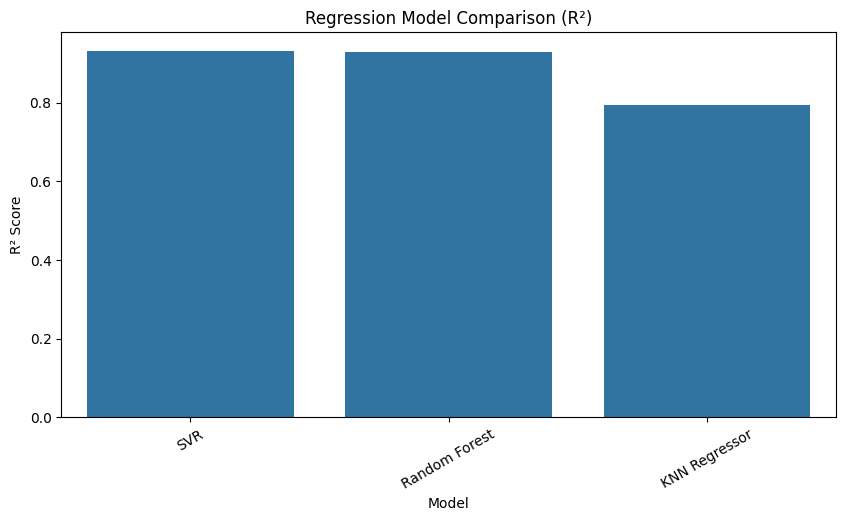

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.barplot(
    data=comparison.reset_index(),
    x='index',
    y='R2'
)

plt.xticks(rotation=30)
plt.title("Regression Model Comparison (R²)")
plt.ylabel("R² Score")
plt.xlabel("Model")

plt.show()

### Observation

**Performance:** A KNN Classifier achieved a Training Accuracy of 0.7782 and a Test Accuracy of 0.7710 after hyperparameter tuning using GridSearchCV.

**Best Hyperparameters:**
- `n_neighbors`: 15
- `weights`: 'distance'
- `metric`: 'euclidean'

**Diagnosis:** The model shows moderate performance for player tier classification. There is a small drop between training and test accuracy, indicating acceptable generalization but overall weaker results compared to previous models (Random Forest and SVM).

**Final Evaluation:** The KNN Classifier delivers the lowest performance among the tested models (Test Accuracy = 0.7710). While the distance-weighted approach with 15 neighbors helps, the model struggles to achieve competitive accuracy, suggesting it may not be the best choice for this classification task.

# Model Predictions: Valuation and Performance Tier

In [ ]:
def predict_new_player(age, future_potential, total_stats_score, position, country):

    new_player = pd.DataFrame([{
        'Age':               age,
        'Future Potential':  future_potential,
        'Total_Stats Score': total_stats_score,
        'Position':          position,
        'Country':           country,
    }])

    new_player_transformed = preprocessor.transform(new_player)

    reg_results = {
        "Random Forest": round(grid_search_rf.predict(new_player_transformed)[0], 3),
        "SVR":           round(grid_search_svr.predict(new_player_transformed)[0], 3),
        "KNN":           round(grid_knn_reg.predict(new_player_transformed)[0], 3),
    }

    clf_results = {
        "Random Forest": grid_search_clf.predict(new_player_transformed)[0],
        "SVC":           grid_search_svc.predict(new_player_transformed)[0],
        "KNN":           grid_knn_clf.predict(new_player_transformed)[0],
    }

    print("*" * 45)
    print(f"  Player: {position} | {country} | Age {age}")
    print("*" * 45)
 
    print("\n Value Prediction (M$):")
    for model, val in reg_results.items():
        print(f"   {model:<15} → {val} M$")
 
    print("\n  Tier Classification:")
    for model, tier in clf_results.items():
        print(f"   {model:<15} → {tier}")
 
    print("=" * 45)
 
    return {"regression": reg_results, "classification": clf_results}

In [ ]:
# testing 1

result = predict_new_player(
    age               = 23,
    future_potential  = 85,
    total_stats_score = 2050,
    position          = 'ST',
    country           = 'France'
)

*********************************************
  Player: ST | France | Age 23
*********************************************

 Value Prediction (M$):
   Random Forest   → 29.12 M$
   SVR             → 37.988 M$
   KNN             → 30.516 M$

  Tier Classification:
   Random Forest   → Elite
   SVC             → Elite
   KNN             → Elite


In [ ]:
# testing 2

result = predict_new_player(
    age               = 19,
    future_potential  = 91,
    total_stats_score = 1950,
    position          = 'CM',
    country           = 'England'
)

*********************************************
  Player: CM | England | Age 19
*********************************************

 Value Prediction (M$):
   Random Forest   → 70.135 M$
   SVR             → 56.029 M$
   KNN             → 52.763 M$

  Tier Classification:
   Random Forest   → Elite
   SVC             → Elite
   KNN             → Elite


# Creating JSON File 

In [ ]:
results = {
  "group_members": [
    {"name": "Ahmed fared abdo", "ID": "2401244764"},
    {"name": "Joumana mohamed osman", "ID": "2401244571"},
    {"name": "mariam hisham mahmoud", "ID": "2401245043"},
    {"name": "nouran mohamed ibrahim", "ID": "2401247405"},
    {"name": "mariam ayman hafez", "ID": "2401249964"}
  ],
  "best_hyperparameters": {
    "RandomForestClassifier": {
      "n_estimators": 100,
      "max_depth": "null",
      "criterion": "entropy"
    },
    "SVC": {
      "C": 1,
      "kernel": "rbf",
      "gamma": "scale"
    },
    "KNNClassifier": {
      "n_neighbors": 15,
      "weights": "distance",
      "metric": "euclidean"
    },
    "SVR": {
      "C": 100,
      "epsilon": 0.1,
      "kernel": "rbf"
    },
    "KNNRegressor": {
      "n_neighbors": 11,
      "weights": "distance"
    }
  },
  "cv_stability": {
    "RandomForestClassifier": {
      "mean": 0.8357,
      "std": 0.0071
    },
    "RandomForestRegressor":{
      "mean":0.9519,
      "std":0.0358

    },
    "SVC": {
      "mean": 0.8553,
      "std": 0.0082
    },
    "KNNClassifier": {
      "mean": 0.7782,
      "std": 0.0067
    },
    "SVR": {
      "mean": 0.9287,
      "std": 0.0170
    },
    "KNNRegressor": {
      "mean": 0.8138,
      "std": 0.0236
    }
  }
}

In [ ]:
import json

with open('results.json', 'w') as f:
    json.dump(results, f, indent=4)

print("results.json has been created successfully!")

results.json has been created successfully!


#  Analysis and Discussion



## 8.1 Model Comparison
**Which model performed best overall for regression, and which for classification?**

- **Regression**: Ridge Regression performed best overall.
- **Classification**: Logistic Regression performed best (mean CV accuracy ≈ 0.61 vs 0.53 for Naïve Bayes).

**Is classification easier or harder than regression on this dataset? Why?**

Classification is **harder** than regression on this dataset. Predicting a player's market value (`Value Per M$`) or overall stats is easier because the numerical features (`Overall_Rating`, `Future Potential`, `Total_Stats Score`) have a strong linear relationship with the target. On the other hand, predicting the exact `Position` is more challenging due to the large number of classes and significant overlap in player attributes across similar positions.

## 8.2 Regularization Analysis

**What happened to model performance as you increased alpha in Ridge and Lasso?**

As alpha increased:
- Ridge performance degraded **gradually** (smooth shrinkage).
- Lasso performance degraded **more sharply** because it started eliminating many features.

**Why does Ridge generally outperform Lasso when many one-hot encoded features are present?**

Ridge generally outperforms Lasso in the presence of many one-hot encoded features because:
- It handles multicollinearity better by shrinking coefficients without setting them exactly to zero.
- Lasso tends to arbitrarily pick one feature from a group of highly correlated dummies and discard the rest, leading to information loss.
- Ridge provides more stable and robust models when dealing with high-dimensional categorical data after one-hot encoding.